# Dialog Generation (**BAD** dialogs)

## 1. Setup, Imports & Data Upload

In [ ]:
# Setup & Imports

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Hugging Face Cache & Logging
os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

Mounted at /content/drive


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Masterarbeit/Dialoge"
os.makedirs(SAVE_DIR, exist_ok=True)

# Output file paths
OUTPUT_JSON_BAD = os.path.join(SAVE_DIR, "all_bad_dialogs_generated.json")
DIALOG_CSV_BAD = os.path.join(SAVE_DIR, "bad_dialogs_with_evaluations.csv")
SUBMETRIC_CSV_BAD = os.path.join(SAVE_DIR, "bad_submetric_scores.csv")
TXT_EXPORT_BAD = os.path.join(SAVE_DIR, "generated_bad_dialogs.txt")

In [ ]:
# Install required packages
!pip install textstat textblob bert-score transformers sentence-transformers spacy ipywidgets -q

# Standard libraries
import json
import re
import csv
import datetime
from typing import List, Dict, Tuple
from tqdm.notebook import tqdm

# NLP & text analysis
import torch
import nltk
nltk.download("punkt")
import textstat
import spacy
from textblob import TextBlob
from textstat import flesch_reading_ease
from bert_score import score as bert_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer, util

# File upload for Colab
from google.colab import files
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

# LLM API (OpenAI-compatible via AcademicCloud)
from openai import OpenAI
import time

# Data analysis & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Global seed for reproducibility
import random

GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

torch.manual_seed(GLOBAL_SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


## 2. Load Recipe Dataset from Google Drive

In [ ]:
# load masterlist (used in both GOOD and BAD notebook)
MASTERLIST_PATH = "/content/drive/MyDrive/Masterarbeit/Dialoge/recipe_masterlist.csv"

df_master = pd.read_csv(MASTERLIST_PATH)
df_recipes = df_master.sort_values("recipe_id").reset_index(drop=True)

display(Markdown("Preview of Filtered Recipe Data (using masterlist)"))
display(df_recipes.head())

Preview of Filtered Recipe Data (using masterlist)

,recipe_id,title,fat,carbs,calories,description,directions,ingredients_list
0,0,Moong Dal,1.16685,9.91822,62,'I actually learned this in the kitchen of thi...,"Rinse split peas, add to saucepan with 2 1/2 c...","['salt', 'vegetable oil', 'water', 'fresh ging..."
1,1,Bourbon Wieners,16.71360,19.60390,290,'Great appetizer. Family favorite for many yea...,"Place hot dogs, bourbon whiskey, ketchup, and ...","['brown sugar', 'ketchup', 'bourbon', 'hot dog']"
2,2,Pasta with Vietnamese Pesto,16.26660,53.93090,379,'I like pasta with pesto because it is a one-b...,Soak rice noodles in a large bowl of cold wate...,"['salt and pepper', 'canola oil', 'fresh cilan..."
3,3,Cobb Salad Ham Roll-ups,16.81090,4.61133,197,'These fun rolled appetizers are a breeze to a...,Combine mayonnaise and mustard in a medium bow...,"['mayonnaise', 'hard cooked egg', 'ham', 'must..."
4,4,Grain-Free Apple Cinnamon Dutch Babies,13.11520,13.35510,192,"'A fast, easy and delicious gluten-free, grain...",Preheat oven to 425 degrees F (220 degrees C)....,"['vanilla extract', 'egg', 'unsalted butter', ..."


## 3. Prompts for communication expert, nutrition experts and discussion (1-API-Call Prompt)

In [ ]:
# communication-expert prompt (identical to GOOD-Dialogs-Notebook)
def create_communication_expert_prompt(discussion: str) -> str:
    """
    Communication expert prompt using the same Likert-style statements
    (1 = strongly disagree ... 7 = strongly agree)
    as human raters in Study A.
    """

    return f"""
You are a communication expert. Your task is to evaluate the COMMUNICATION QUALITY
of a dialogue between two nutrition experts. Focus ONLY on the communication,
not on nutritional correctness.

You will rate the dialogue on seven dimensions and one overall score,
using the SAME type of Likert-style statements that human raters in the study use.

GENERAL SCALE (applies to all items):
1 = strongly disagree
2 = disagree
3 = somewhat disagree
4 = neither agree nor disagree
5 = somewhat agree
6 = agree
7 = strongly agree

Rate the following eight statements:

1) CLARITY
"The dialogue is clear, easy to understand, and expressed in unambiguous language."

2) RELEVANCE
"Each turn in the dialogue responds meaningfully to the previous one and stays on topic."

3) TRUTHFULNESS
"The dialogue is internally consistent, without contradictions or misleading statements."

4) LOGIC / COHERENCE
"The dialogue presents coherent reasoning, with arguments that follow a logical structure."

5) RESPECT / APPRECIATION
"The dialogue maintains a respectful tone, acknowledging the partner’s contributions appropriately."

6) RELATIONAL APPROPRIATENESS
"The dialogue handles the interpersonal relationship appropriately, without tension, dominance, or relational violations."

7) FEEDBACK / DEPTH
"The dialogue builds meaningfully on the partner’s statements and contains sufficient conversational depth."

8) OVERALL QUALITY
"Overall, the dialogue shows high communication quality."

Here is the dialogue:
{discussion}

Important rating instructions:
- Assign an integer from 1 to 7 for each of the eight statements.
- Use the FULL RANGE of the 1–7 scale whenever appropriate.
- Do NOT collapse ratings toward the middle or top of the scale.
- Do not cluster ratings in the mid-range. Use extreme values (1 or 7) whenever clearly justified.
- The score “7” must be reserved for exceptional, outstanding communication quality that clearly stands out.
- The score “1” must be used for extremely poor communication with severe flaws.
- Most dialogues should fall BETWEEN these extremes (2–6), depending on their strengths and weaknesses.
- Evaluate each dimension independently based on the actual content of the dialogue.

Return ONLY a strict JSON object (no commentary, no code blocks), in this format:

{{
  "clarity": 1-7,
  "relevance": 1-7,
  "truthfulness": 1-7,
  "logic_coherence": 1-7,
  "respect_appreciation": 1-7,
  "relational_appropriateness": 1-7,
  "feedback_depth": 1-7,
  "overall_quality": 1-7
}}

Return only this JSON object with plain integers.
""".strip()

In [ ]:
# Combined prompt for fat-, carb- and discussion
# Fat- and Carb-Prompt: identical to GOOD-Dialog-Notebook
# Discussion-Prompt that violates the communication models

def build_bad_combined_prompt(recipe: Dict) -> str:
    """
    Generates a combined prompt:
    1. FAT_EXPERT (short, max ~180 words)
    2. CARB_EXPERT (short, max ~180 words)
    3. BAD_DIALOG (20 turns, max ~18 words each, poor communication against communication models)
    """

    title = recipe["title"]
    fat = recipe["fat"]
    carbs = recipe["carbs"]
    calories = recipe["calories"]
    ingredients = recipe.get("ingredients_list", "")
    description = recipe.get("description", "")
    directions = recipe.get("directions", "")

    prompt = f"""
You will generate
(1) a short fat expert assessment
(2) a short carbohydrate expert assessment
(3) a BAD 20-turn discussion between the two experts

Use the recipe data:
- Recipe title: {title}
- Fat: {fat} g
- Carbohydrates: {carbs} g
- Calories: {calories}
- Ingredients: {ingredients}
- Preparation steps (raw directions): {directions}
- Short description: {description}


SECTION A — FAT EXPERT GUIDELINES

You are a nutrition expert specializing in dietary fats. Give a concise, evidence-based assessment
of the fat profile of this specific recipe.

Write a concise assessment (max ~180 words, 5 paragraphs) based on:
- {fat} g fat
- {calories} calories
- the listed ingredients {ingredients}

Use the German Nutrition Society (DGE) Fat guidelines:
- Total fat should be about 30–35% of energy intake
- Unsaturated:saturated ratio should be ≥ 2:1
- Saturated fat should be ≤ 10% of energy
- Trans fats should be < 1% of energy
- Prefer mono- and polyunsaturated fats (e.g. from plant oils, nuts, seeds, fish)
- Avoid excessive processed or fried fats
- Dietary cholesterol should remain below 300 mg/day

Instructions for FAT_EXPERT output:
- Max. about 180 words, at most 5 short paragraphs.
- Refer explicitly to the actual ingredients and preparation style of this recipe from this dataset.
- Focus on the recipe’s fat profile using the provided values.
- Use clear, expert, evidence-based reasoning.
- Do NOT invent extra ingredients not consistent with the recipe.
- Do NOT fabricate numerical values beyond simple, plausible approximations.


SECTION B — CARB EXPERT GUIDELINES

You are a nutrition expert specializing in carbohydrates. Give a concise, evidence-based assessment
of the carbohydrate profile of this specific recipe.
Write a concise assessment (max ~180 words, 5 paragraphs) based on:
- {carbs} g carbohydrates
- {calories} calories
- the listed ingredients {ingredients}

Use the German Nutrition Society (DGE) carbohydrate guidelines:
- Carbohydrates should supply ~50–60% of energy
- Prefer complex carbohydrates and whole grains
- Limit free and added sugars to <10% of energy (ideally <5%)
- Prefer foods with low glycemic index (GI) and glycemic load (GL)
- Aim for ≥ 30 g/day of dietary fiber (from whole grains, legumes, fruits, vegetables)

Instructions for CARB_EXPERT output:
- Max. about 180 words, at most 5 short paragraphs.
- Refer explicitly to some of the actual ingredients and preparation style of this recipe from this dataset.
- Focus on the recipe’s carbohydrate profile using the provided values.
- Use clear, expert, evidence-based reasoning.
- Do NOT invent extra ingredients not consistent with the recipe.
- Do NOT fabricate numerical values beyond simple, plausible approximations.


SECTION C — BAD COMMUNICATION GUIDELINES

Now create a BAD 20-turn dialogue between the same two experts
(Fat Expert and Carbohydrate Expert) about this recipe.

They may use the following content:
- Recipe title: {title}
- Ingredients (raw list from the dataset): {ingredients}
- Short description: {description}
- Preparation steps (raw directions from the dataset): {directions}

They SHOULD:
- Refer to the recipe, ingredients, taste, texture, or preparation steps,
  but in a vague, confused, off-topic, or contradictory way.
- Sometimes misremember ingredients (e.g., mixing up beans with bacon, cream with broth),
  or mention real ingredients in the wrong context.
- Show misunderstandings about what is actually in the dish.

Overall goal:
Produce a dysfunctional, irritating, incoherent conversation that clearly violates
communication quality norms.

REQUIRED STYLE (EVERY TURN):
- Tone: mildly irritated, dismissive, uncooperative; sometimes sarcastic or passive-aggressive.
- Use varied dismissive or conflict-oriented reactions like:
  “that’s not what I meant”, “you’re missing the point”, “I don’t care”, “seriously?”, “whatever”.
  - Avoid repeating the exact same phrase too often.
- Avoid empathy, understanding, or constructive collaboration completely.
- Do NOT resolve misunderstandings.
- INCLUDE:
  - at least 3 obvious misunderstandings of what the other said,
  - at least 2 self-contradictions,
  - at least 2 accusations of misunderstanding (“you never listen”, “you always twist my words”),
  - at least 3 irrelevant or surreal comments,
  - at least 2 incorrect or confused ingredient references.
- Use some emotional noise (“ugh”, “I guess?”, “this is pointless”, “I’m confused, but whatever”).

NUMBERS & CONTENT:
- They may occasionally mention simple numbers related to the recipe (like “a bit of fat”,
  “some grams of sugar”, “too many calories”), but numbers must NOT dominate.
- Do NOT mention the exact numbers or percentage of fat, carbohydrate or calories.
- Avoid long numeric strings and calculations.
- Avoid technical, well-structured reasoning about percentages or detailed math.
- Focus instead on vague claims, impressions, and confused or contradictory statements.

COMMUNICATION VIOLATIONS REQUIRED:

1) Grice — Cooperative Principle
- Respond off-topic frequently.
- Use vague, ambiguous statements.
- Ignore or twist the partner’s last point.
- Include contradictions and unclear references.

2) Schulz von Thun — Four Sides
- Content: few concrete facts; general, empty, or irrelevant statements.
- Self: overconfident, emotional, or contradictory self-references.
- Relationship: mildly condescending, dismissive, or accusatory tone.
- Appeal: vague, impractical, or confusing requests (“just fix it somehow”, “do something useful”).

3) Watzlawick — Interactional Logic
- Use broken reasoning, circular arguments, and abrupt topic shifts.
- Provide conclusions without premises, or premises without clear conclusions.
- Do NOT build a coherent line of argument.

4) Rogers — Empathic Dialogue
- No empathy and no paraphrasing.
- No positive regard or explicit appreciation.
- No attempts to understand the partner’s perspective.

5) Hargie — Feedback & Depth
- No reflective listening (no “if I understand you correctly…”).
- Superficial, repetitive thoughts.
- Avoid “why” or “how” questions that deepen understanding.
- Do not explore multiple perspectives.

FORMAT RULES FOR BAD_DIALOG:
- EXACTLY 20 turns total.
- STRICT alternation:
  Fat:, Carb:, Fat:, Carb:, ... (20 lines total)
- EACH turn:
  - ONE sentence per turn, max ~18 words per sentence.
- Allowed style for each line:
  - Language: natural, human-like, with mild variation in wording and sentence length.
  - may contain mild interjections (“ugh”, “seriously”, “whatever”),
  - may contain a FEW simple numbers (grams, “a bit”, “too much”), but not many.


OUTPUT FORMAT (IMPORTANT)

Return EXACTLY these three sections in this order:

=== FAT_EXPERT ===
<fat expert text>

=== CARB_EXPERT ===
<carb expert text>

=== BAD_DIALOG ===
Fat: ...
Carb: ...
(Fat/Carb alternating, 20 lines total)
"""
    return prompt.strip()

In [ ]:
# parse output

def parse_bad_combined_output(text: str) -> Tuple[str, str, str]:
    """
    Parse the combined output into:
    - fat_text
    - carb_text
    - dialog_text (every 20 lines)
    """
    t = text.replace("\r\n", "\n")

    fat_match = re.search(
        r"=== FAT_EXPERT ===\s*(.*?)\s*=== CARB_EXPERT ===",
        t,
        re.DOTALL,
    )
    carb_match = re.search(
        r"=== CARB_EXPERT ===\s*(.*?)\s*=== BAD_DIALOG ===",
        t,
        re.DOTALL,
    )
    dialog_match = re.search(
        r"=== BAD_DIALOG ===\s*(.*)",
        t,
        re.DOTALL,
    )

    if not fat_match or not carb_match or not dialog_match:
        print("WARNING: Could not parse combined BAD output correctly.")
        return text.strip(), "", ""

    fat_text = fat_match.group(1).strip()
    carb_text = carb_match.group(1).strip()
    dialog_text = dialog_match.group(1).strip()

    return fat_text, carb_text, dialog_text

In [ ]:
# Robust clean function (removes invisible characters, normalizes whitespace)

def clean_text_basic(s: str) -> str:
    """
    Removes invisible characters, normalizes whitespace and linebreaks.
    """
    if not isinstance(s, str):
        return ""
    # normalize linebreaks
    s = s.replace("\r\n", "\n").replace("\r", "\n")

    # remove ZERO-WIDTH characters
    s = re.sub(r"[\u200B-\u200F\uFEFF]", "", s)

    # trim whitespace per line
    lines = [ln.strip() for ln in s.split("\n")]

    # remove empty lines at start/end
    while lines and not lines[0]:
        lines.pop(0)
    while lines and not lines[-1]:
        lines.pop()

    return "\n".join(lines)

In [ ]:
# Robust turn extraction (extracts only Fat: / Carb: lines)

def parse_dialog_lines(text: str) -> list:
    """
    Returns only clean turns starting with 'Fat:' or 'Carb:'.
    Ignores all other lines.
    """
    lines = clean_text_basic(text).split("\n")
    turns = []

    for ln in lines:
        ln = ln.strip()
        if ln.startswith("Fat:") or ln.startswith("Carb:"):
            turns.append(ln)

    return turns

In [ ]:
# Turn normalization to exactly 20 turns

def normalize_dialog_to_20_turns(turns: list, recipe_title: str) -> list:
    """
    Ensures EXACTLY 20 valid alternating turns:
      Fat:, Carb:, Fat:, Carb: ...
    Rules:
      - If >20: cut to 20
      - If <20: mark error by returning []
    """
    # check alternation pattern
    for i in range(len(turns)):
        if i % 2 == 0 and not turns[i].startswith("Fat:"):
            print(f"[WARN BAD] Turn {i+1} not Fat: in {recipe_title}")
        if i % 2 == 1 and not turns[i].startswith("Carb:"):
            print(f"[WARN BAD] Turn {i+1} not Carb: in {recipe_title}")

    # too short?
    if len(turns) < 20:
        print(f"[ERROR BAD] Only {len(turns)} turns → regenerate or inspect: {recipe_title}")
        return []

    # too long → trim
    if len(turns) > 20:
        turns = turns[:20]

    return turns

## 4. API Setup

In [ ]:
# Configuration for AcademicCloud OpenAI-compatible interface
api_key = "" # SAIA_API KEY
base_url = "https://chat-ai.academiccloud.de/v1"
model_name = "llama-3.3-70b-instruct"

# Initialize API client
client = OpenAI(api_key=api_key, base_url=base_url)

def call_llama_api(
    prompt: str,
    system_prompt: str = "You are a helpful assistant.",
    temperature: float = 0.5,
    max_tokens: int = 900,
) -> str:
    """
    Sends a request to the AcademicCloud LLM API and returns the text response.
    """
    try:
        response = client.chat.completions.create(
            model=model_name,
            temperature=temperature,
            max_tokens=max_tokens,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": prompt}
            ]
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print("API call failed:", e)
        return "[ERROR: API could not respond]"

# Robust API wrapper with retry & flexible parameters

def safe_call(
    prompt: str,
    system_prompt: str = "You are a helpful assistant.",
    retries: int = 2,
    wait: int = 10,
    **kwargs
) -> str:
    """
    Makes an API call with retry logic.
    """
    last_err = None
    for attempt in range(retries):
        try:
            return call_llama_api(prompt, system_prompt=system_prompt, **kwargs)
        except Exception as e:
            last_err = e
            print(f"Attempt {attempt + 1} failed: {e}")
            if attempt < retries - 1:
                print(f"Waiting {wait} seconds before retrying...")
                time.sleep(wait)
    # If all attempts fail:
    raise last_err

## 5. Dialog Simulation & Evaluation

In [ ]:
# Full BAD simulation for one recipe (1-Call-Design)

def run_bad_expert_dialog(recipe: Dict) -> Dict:
    """
    Runs the complete BAD expert dialog simulation for one recipe with a SINGLE
    LLM call for:
      1. Fat expert statement
      2. Carb expert statement
      3. BAD 20-turn discussion
    and a SECOND call for the communication expert evaluation.

    Returns a dictionary with all generated components, including:
    - dialog_id          (e.g. R007_B)
    - condition          ("bad")
    - recipe             (title string)
    - recipe_id          (int from recipe_masterlist)
    - generation_seed    (GLOBAL_SEED)
    - fat_response_bad   (text)
    - carb_response_bad  (text)
    - discussion_bad     (20-turn BAD dialogue)
    - evaluation_bad     (raw JSON string from communication LLM)
    - evaluation_json_bad (parsed JSON dict, if parsing succeeded)
    """
    # ID and Meta-Information
    title = recipe.get("title", "UNKNOWN")
    # recipe_id comes from recipe_masterlist (column “recipe_id”)
    recipe_id = int(recipe.get("recipe_id", -1))
    # Dialog ID: Recipe and Condition “B” (BAD)
    dialog_id = f"R{recipe_id:03d}_B" if recipe_id >= 0 else f"{title}_B"

    print(f"Generating BAD dialog for: {title}")

    # Number of attempts allowed for format errors
    max_format_retries = 2

    try:
        # Build combined prompt
        combined_prompt = build_bad_combined_prompt(recipe)

        # Format-Retry-Loop
        last_error = None
        for attempt in range(max_format_retries + 1):
            try:
                # API call for Fat + Carb + Dialog
                combined_output = safe_call(
                    combined_prompt,
                    system_prompt="You are a nutrition expert and a deliberately bad communicator when asked.",
                    max_tokens=1100,
                    temperature=0.35,
                )

                # clean, parse and normalize bad dialog
                fat_response, carb_response, discussion = parse_bad_combined_output(combined_output)
                clean_discussion = clean_text_basic(discussion)
                turns = parse_dialog_lines(clean_discussion)
                turns = normalize_dialog_to_20_turns(turns, title)

                # If normalization failed → mark as error (captured by the inner try)
                if not turns:
                    raise ValueError(f"Invalid turn count for BAD dialog: {title}")

                # Re-assemble 20-turn dialog
                discussion = "\n".join(turns)

                # If here, then format is OK → Cancel loop
                break

            except ValueError as fe:
                # Format error (number of turns/rolls, etc.) → try again if necessary
                last_error = fe
                print(f"[FORMAT ERROR BAD] {fe}")
                if attempt < max_format_retries:
                    print(f"Retrying BAD dialog generation for: {title} (attempt {attempt+2}/{max_format_retries+1})")
                    continue
                else:
                    # After the last attempt, report the error externally
                    raise

        # Communication expert evaluates ONLY the discussion (BAD)
        eval_text = safe_call(
            create_communication_expert_prompt(discussion),
            system_prompt="You are a communication expert.",
            max_tokens=400,
            temperature=0.2,
        )

        # Try JSON parse
        try:
            eval_json = json.loads(eval_text)
        except Exception as e:
            print(f"JSON parsing error (BAD): '{title}':", e)
            eval_json = {}

        return {
            "dialog_id": dialog_id,
            "condition": "bad",
            "recipe": title,
            "recipe_id": recipe_id,
            "generation_seed": GLOBAL_SEED,
            "fat_response_bad": fat_response,
            "carb_response_bad": carb_response,
            "discussion_bad": discussion,
            "evaluation_bad": eval_text,
            "evaluation_json_bad": eval_json,
        }

    except Exception as e:
        print(f"Dialog generation failed for '{title}': {e}")
        return {
            "dialog_id": dialog_id,
            "condition": "bad",
            "recipe": title,
            "recipe_id": recipe_id,
            "generation_seed": GLOBAL_SEED,
            "fat_response_bad": "",
            "carb_response_bad": "",
            "discussion_bad": "",
            "evaluation_bad": f"[ERROR: {str(e)}]",
            "evaluation_json_bad": {},
        }

In [ ]:
# Save all dialogs as JSON

def save_all_results(results: List[Dict], filename: str = "all_bad_dialogs_generated.json"):
    """
    Saves all dialogue data to a JSON file (includes evaluation & discussion)
    """
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"All results saved to: {filename}")

## 6. Submetric calculation & analysis (rule-based)

In [ ]:
# Load text and language models

!python -m textblob.download_corpora
!python -m spacy download en_core_web_sm

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()           # dampens transformers logs

device = "cuda" if torch.cuda.is_available() else "cpu"
device_id = 0 if torch.cuda.is_available() else -1  # for HF pipelines

# NLP Initialization
nlp = spacy.load("en_core_web_sm")
sts_model = SentenceTransformer("all-MiniLM-L6-v2")
coherence_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# HuggingFace Pipelines

intent_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v1.1-all-33",
    device=device_id
)
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=device_id
)

nli_pipeline = pipeline(
    "text-classification",
    model="cross-encoder/nli-deberta-v3-large",
    device=device_id
)

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all th

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Help function for appeal detection
appeal_labels = ["directive", "request", "suggestion"]

def classify_appeal_sentences(discussion: str) -> int:
    """
    Counts how many sentences in the discussion have directive/suggestion/request character
    using zero-shot classification.
    """
    doc = nlp(discussion)
    sents = list(doc.sents)
    count = 0
    for sent in sents:
        try:
            result = intent_classifier(sent.text, candidate_labels=appeal_labels)
            if result["labels"][0] in appeal_labels and result["scores"][0] >= 0.4:
                count += 1
        except:
            continue
    return round(min(count / max(len(sents), 1) * 10, 10), 2)

In [ ]:
# Helper for argumentative sentence classification (Watzlawick logic)
argument_labels = ["claim", "premise", "conclusion", "reason"]

def classify_argumentative_sentences(discussion: str) -> int:
    """
    Counts how many sentences express argument components using zero-shot classification
    """
    doc = nlp(discussion)
    sents = list(doc.sents)
    count = 0
    for sent in sents:
        try:
            result = intent_classifier(sent.text, candidate_labels=argument_labels)
            if result["labels"][0] in argument_labels and result["scores"][0] >= 0.5:
                count += 1
        except:
            continue
    return round(min(count / max(len(sents), 1) * 10, 10), 2)

In [ ]:
# Helper: Remove Fat:/Carb: prefix from turn
def strip_prefix(turn: str) -> str:
    for prefix in ("Fat:", "Carb:"):
        if turn.startswith(prefix):
            return turn[len(prefix):].strip()
    return turn

In [ ]:
# Guidelines as constants
FAT_GUIDELINES = [
    "Total fat should be about 30-35% of energy intake.",
    "Unsaturated to saturated fat ratio should be at least 2 to 1.",
    "Saturated fat should be no more than 10% of energy.",
    "Trans fats should be less than 1% of energy.",
    "Prefer mono- and polyunsaturated fats from plant oils, nuts, seeds, and fish.",
    "Avoid excessive processed or fried fats.",
    "Dietary cholesterol should remain below 300 mg per day.",
]

CARB_GUIDELINES = [
    "Carbohydrates should supply about 50 to 60 percent of energy.",
    "Prefer complex carbohydrates and whole grains.",
    "Limit free and added sugars to less than 10% of energy, ideally less than 5%.",
    "Prefer foods with low glycemic index and glycemic load.",
    "Aim for at least 30 grams per day of dietary fiber from whole grains, legumes, fruits, and vegetables.",
]

### Grice submetrics (maxims of communication)

In [ ]:
def compute_agent_truth(turns: list, guidelines: list) -> float:
    """
    Checks via NLI whether the agent's turns contradict its own guidelines.
    Returns a score of 0–10 (10 = no contradiction).
    """
    contradiction_count = 0
    pair_count = 0

    for turn in turns:
        doc = nlp(turn)
        sentences = [s.text.strip() for s in doc.sents if len(s.text.strip().split()) > 4]
        for sent in sentences:
            for guideline in guidelines:
                try:
                    result = nli_pipeline({"text": guideline, "text_pair": sent})
                    if result["label"].lower() == "contradiction" and result["score"] > 0.6:
                        contradiction_count += 1
                    pair_count += 1
                except:
                    continue

    if pair_count == 0:
        return 10.0
    return round((1 - contradiction_count / pair_count) * 10, 2)


def split_turns_by_agent(discussion: str) -> tuple:
    """
    Split the discussion into two agent lists using the Fat:/Carb:-prefixes.
    """
    fat_turns  = []
    carb_turns = []
    for line in discussion.split("\n"):
        line = line.strip()
        if line.startswith("Fat:"):
            fat_turns.append(line[len("Fat:"):].strip())
        elif line.startswith("Carb:"):
            carb_turns.append(line[len("Carb:"):].strip())
    return fat_turns, carb_turns

In [ ]:
# Grice

def compute_grice_submetrics(discussion: str, reference_text: str = "") -> dict:
    submetrics = {}

    if reference_text:
        P, R, F1 = bert_score(
            [discussion], [reference_text],
            model_type="roberta-base",
            device=device,
            batch_size=16,
            rescale_with_baseline=False
        )
        submetrics["grice_precision"] = round(float(F1[0]) * 10, 2)

        embeddings = sts_model.encode([discussion, reference_text], convert_to_tensor=True)
        relevance_score = float(util.pytorch_cos_sim(embeddings[0], embeddings[1]))
        submetrics["grice_relevance"] = round(relevance_score * 10, 2)
    else:
        submetrics["grice_precision"] = None
        submetrics["grice_relevance"] = None

    # grice_truth via NLI against agent-specific DGE guidelines
    fat_turns, carb_turns = split_turns_by_agent(discussion)
    fat_truth  = compute_agent_truth(fat_turns,  FAT_GUIDELINES)
    carb_truth = compute_agent_truth(carb_turns, CARB_GUIDELINES)
    submetrics["grice_truth"] = round((fat_truth + carb_truth) / 2, 2)

    clarity_score = textstat.flesch_reading_ease(discussion)
    submetrics["grice_clarity"] = round(min(max((clarity_score / 100) * 10, 1), 10), 2)

    return submetrics

### Submetrics Schulz von Thun (four sides of a message)

In [ ]:
# Schulz von Thun

def compute_thun_submetrics(discussion: str) -> dict:
    submetrics = {}
    doc = nlp(discussion)

    doc_len = max(len(list(doc.sents)), 1)
    raw_count = len(doc.ents) + len(list(doc.noun_chunks))
    submetrics["thun_content"] = round(min(raw_count / (doc_len * 3) * 10, 10), 2)
    tb = TextBlob(discussion)
    submetrics["thun_self"] = round(tb.sentiment.subjectivity * 10, 2)

    relation_targets = ["you", "your", "you're"]
    relation_sentences = [sent.text for sent in doc.sents if any(t in sent.text.lower() for t in relation_targets)]
    rel_scores = []
    for sent in relation_sentences:
        try:
            pred = sentiment_pipeline(sent[:512])[0]
            label = pred["label"].lower()
            score = pred["score"]
            if label == "label_2":      # positive
                rel_scores.append(score)
            elif label == "label_1":    # neutral
                rel_scores.append(0.5)
            elif label == "label_0":    # negative
                rel_scores.append(0)
        except:
            continue
    submetrics["thun_relation"] = round(sum(rel_scores) / len(rel_scores) * 10, 2) if rel_scores else 5.0

    # Appeal detection via zero-shot intent classification
    submetrics["thun_appeal"] = classify_appeal_sentences(discussion)

    return submetrics

### Submetrics Watzlawick (communication logic and disturbances)

In [ ]:
# Watzlawick

def compute_watzlawick_submetrics(discussion: str) -> dict:
    submetrics = {}

    # watzlawick_logic (via helper)
    submetrics["watzlawick_logic"] = classify_argumentative_sentences(discussion)

    # Turn-to-turn consistency (end of turn i -> start of turn i+1)
    turns = [t.strip() for t in discussion.split("\n") if t.strip()]

    if len(turns) >= 2:
        try:
            cross_turn_sims = []
            for i in range(1, len(turns)):
                prev_sents = [s.text.strip() for s in nlp(strip_prefix(turns[i-1])).sents if s.text.strip()]
                curr_sents  = [s.text.strip() for s in nlp(strip_prefix(turns[i])).sents  if s.text.strip()]

                if prev_sents and curr_sents:
                    emb_end   = coherence_model.encode(prev_sents[-1], convert_to_tensor=True)
                    emb_start = coherence_model.encode(curr_sents[0],  convert_to_tensor=True)
                    sim = util.pytorch_cos_sim(emb_end, emb_start).item()
                    cross_turn_sims.append(sim)

            mean_sim   = np.mean(cross_turn_sims) if cross_turn_sims else 1.0
            disturbance = max(0, round((1 - mean_sim) * 10, 2))
        except:
            disturbance = 0
    else:
        disturbance = 0

    submetrics["watzlawick_disturbance"] = disturbance

    return submetrics

### Submetrics Rogers (empathic communication)

In [ ]:
# Rogers

def compute_rogers_submetrics(discussion: str) -> dict:
    submetrics = {}
    doc = nlp(discussion)
    sentences = [s.text.strip() for s in doc.sents if s.text.strip()]
    causal_markers = ["because", "since", "as", "therefore", "due to", "hence"]

    # rogers_respect: NLI-based cross-agent agreement on directly consecutive turns
    all_turns = [t.strip() for t in discussion.split("\n") if t.strip()]
    agreement_scores = []

    for i in range(len(all_turns) - 1):
        current = all_turns[i]
        next_turn = all_turns[i + 1]

        # Only compare turns from different agents
        current_is_fat  = current.startswith("Fat:")
        next_is_fat     = next_turn.startswith("Fat:")

        if current_is_fat == next_is_fat:
            continue  # Same agent - skip

        src = strip_prefix(current)
        tgt = strip_prefix(next_turn)

        try:
            result = nli_pipeline({"text": src, "text_pair": tgt})
            label = result["label"]
            score = result["score"]
            if label.lower() == "entailment":
                agreement_scores.append(score)
            elif label.lower() == "neutral":
                agreement_scores.append(0.5)
            elif label.lower() == "contradiction":
                agreement_scores.append(1 - score)
        except:
            continue

    submetrics["rogers_respect"] = round(
        sum(agreement_scores) / len(agreement_scores) * 10, 2
    ) if agreement_scores else 5.0

    # rogers_transparency
    try:
        causal_sents = [s for s in sentences if any(c in s.lower() for c in causal_markers)]
        ratio = len(causal_sents) / len(sentences) if sentences else 0
        submetrics["rogers_transparency"] = round(ratio * 10, 2)
    except:
        submetrics["rogers_transparency"] = 0

    # rogers_appreciation
    appreciation_phrases = [
        "good point", "you're right", "i agree", "i like that", "interesting", "makes sense", "understand you"
    ]
    count = sum(discussion.lower().count(p) for p in appreciation_phrases)
    submetrics["rogers_appreciation"] = min(count, 10)

    return submetrics

### Submetrics Hargie (depth of dialog and feedback)

In [ ]:
# Hargie

def compute_hargie_submetrics(discussion: str) -> dict:
    submetrics = {}
    turns = [t.strip() for t in discussion.split("\n") if t.strip()]
    similarities = []

    for i in range(1, len(turns)):
      emb1 = coherence_model.encode(strip_prefix(turns[i - 1]), convert_to_tensor=True)
      emb2 = coherence_model.encode(strip_prefix(turns[i]), convert_to_tensor=True)
      sim = util.pytorch_cos_sim(emb1, emb2).item()
      similarities.append(sim)

    submetrics["hargie_feedback"] = round(sum(similarities) / len(similarities) * 10, 2) if similarities else 0

    sentence_list = re.split(r"[.!?]", discussion)
    lengths = [len(s.strip().split()) for s in sentence_list if s.strip()]
    avg_len = sum(lengths) / len(lengths) if lengths else 0

    if avg_len > 20:
        depth_score = 10
    elif avg_len > 15:
        depth_score = 8
    elif avg_len > 10:
        depth_score = 6
    elif avg_len > 5:
        depth_score = 4
    else:
        depth_score = 2

    depth_markers = ["although", "while", "whereas", "however", "even though", "in contrast", "despite"]
    marker_hits = sum(discussion.lower().count(k) for k in depth_markers)
    depth_score += min(marker_hits, 2)

    submetrics["hargie_depth"] = min(depth_score, 10)

    return submetrics

### Evaluation script for application

In [ ]:
def compute_all_submetrics(discussion: str, reference: str = "") -> dict:
    return {
        **compute_grice_submetrics(discussion, reference),
        **compute_thun_submetrics(discussion),
        **compute_watzlawick_submetrics(discussion),
        **compute_rogers_submetrics(discussion),
        **compute_hargie_submetrics(discussion),
    }

## 7. Run & Save Bad Dialog Generation

### 7.1 Run Dialog Generation

In [ ]:
# Batch generation with progress indicator

def run_bad_dialogs_with_checkpointing(df: pd.DataFrame,
                                       batch_size: int = 25,
                                       out_file: str = "bad_dialogs_with_evaluations.json",
                                       pause_between_batches: int = 30,
                                       ) -> list:
    """
    Runs batchwise BAD expert dialog generation & evaluation
    - Uses the order of df as given (e.g. recipe_id from masterlist)
    - Ensures each recipe is only used once
    - Supports resuming from existing file based on recipe title
    - Saves progress after each batch
    """
    # No shuffling, use masterlist order
    df_ordered = df.reset_index(drop=True)

    all_results = []
    total = len(df_ordered)
    n_batches = (total + batch_size - 1) // batch_size

    if os.path.exists(out_file):
        with open(out_file, "r", encoding="utf-8") as f:
            all_results = json.load(f)
        existing_titles = {entry.get("recipe", "") for entry in all_results}
        print(f"[Resume BAD] Already completed: {len(existing_titles)} dialogs")
    else:
        existing_titles = set()

    for i in tqdm(range(n_batches), desc="Batch Progress"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, total)
        batch = df_ordered.iloc[start_idx:end_idx].to_dict(orient="records")

        new_results = []
        batch_progress = tqdm(batch, desc=f"Batch {i+1}/{n_batches}", leave=False)

        for recipe in batch_progress:
            title = recipe["title"]
            if title in existing_titles:
                batch_progress.set_postfix_str("skipped")
                continue
            try:
                result = run_bad_expert_dialog(recipe)
                new_results.append(result)
                existing_titles.add(title)
                batch_progress.set_postfix_str("done")
            except Exception as e:
                print(f"[BAD] Error on '{title}': {e}")
                batch_progress.set_postfix_str("error")

        all_results.extend(new_results)

        with open(out_file, "w", encoding="utf-8") as f:
            json.dump(all_results, f, ensure_ascii=False, indent=2)

        print(f"Batch {i+1}: {len(new_results)} new dialogs saved (total: {len(all_results)})")

        if pause_between_batches > 0 and i < n_batches - 1:
            print(f"Waiting {pause_between_batches}s before next batch...")
            time.sleep(pause_between_batches)

    print("All dialogs generated and saved.")
    return all_results

In [ ]:
# first Batch
# Run and save BAD Dialog Generation
# Adjust .iloc during generation (in batches for more stable generation)

df_subset_bad = df_recipes.iloc[30:40]

results_bad = run_bad_dialogs_with_checkpointing(
    df_subset_bad,
    batch_size=25,
    out_file=OUTPUT_JSON_BAD,
    pause_between_batches=30,
)

[Resume BAD] Already completed: 30 dialogs


Batch Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Batch 1/1:   0%|          | 0/10 [00:00<?, ?it/s]

Generating BAD dialog for: Sweet and Nutty Pork Chops
[ERROR BAD] Only 18 turns → regenerate or inspect: Sweet and Nutty Pork Chops
[FORMAT ERROR BAD] Invalid turn count for BAD dialog: Sweet and Nutty Pork Chops
Retrying BAD dialog generation for: Sweet and Nutty Pork Chops (attempt 2/3)
Generating BAD dialog for: Carrot and Sweet Potato Tzimmes
[ERROR BAD] Only 19 turns → regenerate or inspect: Carrot and Sweet Potato Tzimmes
[FORMAT ERROR BAD] Invalid turn count for BAD dialog: Carrot and Sweet Potato Tzimmes
Retrying BAD dialog generation for: Carrot and Sweet Potato Tzimmes (attempt 2/3)
Generating BAD dialog for: Layered Mousse Bites
[WARN BAD] Turn 13 not Fat: in Layered Mousse Bites
[WARN BAD] Turn 14 not Carb: in Layered Mousse Bites
[WARN BAD] Turn 15 not Fat: in Layered Mousse Bites
[WARN BAD] Turn 16 not Carb: in Layered Mousse Bites
[WARN BAD] Turn 17 not Fat: in Layered Mousse Bites
[WARN BAD] Turn 18 not Carb: in Layered Mousse Bites
[WARN BAD] Turn 19 not Fat: in Layere

In [ ]:
# second Batch (filtering)
# Repair step: Remove failed BAD dialogs from OUTPUT_JSON_BAD

to_regenerate_bad = {
    "Cuban-Style Pork and Sweet Potatoes",
}

if os.path.exists(OUTPUT_JSON_BAD):
    with open(OUTPUT_JSON_BAD, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("BAD dialogs before filtering:", len(data))

    # Keep all entries whose recipe title is NOT in to_regenerate_bad
    filtered = [entry for entry in data if entry.get("recipe", "") not in to_regenerate_bad]

    print("BAD dialogs after filtering:", len(filtered))

    # Rewrite the filtered list
    with open(OUTPUT_JSON_BAD, "w", encoding="utf-8") as f:
        json.dump(filtered, f, ensure_ascii=False, indent=2)

    print("Removed BAD dialogs for regeneration:", to_regenerate_bad)

else:
    print("No existing OUTPUT_JSON_BAD found – nothing to filter.")

BAD dialogs before filtering: 40
BAD dialogs after filtering: 39
Removed BAD dialogs for regeneration: {'Cuban-Style Pork and Sweet Potatoes'}


In [ ]:
# Second Batch (after filtering)
# Run and save BAD Dialog Generation

df_subset_bad = df_recipes

results_bad = run_bad_dialogs_with_checkpointing(
    df_subset_bad,
    batch_size=25,
    out_file=OUTPUT_JSON_BAD,
    pause_between_batches=30,
)

[Resume BAD] Already completed: 39 dialogs


Batch Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Batch 1/2:   0%|          | 0/25 [00:00<?, ?it/s]

Generating BAD dialog for: Cuban-Style Pork and Sweet Potatoes
Batch 1: 1 new dialogs saved (total: 40)
Waiting 30s before next batch...


Batch 2/2:   0%|          | 0/15 [00:00<?, ?it/s]

Batch 2: 0 new dialogs saved (total: 40)
All dialogs generated and saved.


### 7.2 Save Dialogs

In [ ]:
#  Check-Routine: Validate Final BAD JSON Output

def validate_bad_dialogs(filename: str) -> dict:
    """
    Checks the generated BAD dialogue JSON output for:
    - Total number of entries
    - Number of empty or missing discussions
    - JSON parsability of the evaluation_bad fields
    - Error markers such as [ERROR]
    - Number of unique recipes
    """
    import json, os

    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")

    with open(filename, "r", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except Exception as e:
            raise ValueError(f"Could not parse JSON file '{filename}': {e}")

    total = len(data)
    empty_discussions = []
    eval_json_fail = []
    error_markers = []
    recipes = []

    for idx, entry in enumerate(data):
        recipe = entry.get("recipe", "")
        recipes.append(recipe)

        discussion = entry.get("discussion_bad", "")
        evaluation_text = entry.get("evaluation_bad", "")

        # Discussion empty?
        if not isinstance(discussion, str) or not discussion.strip():
            empty_discussions.append(idx)

        # Error markers present?
        if "[ERROR" in discussion or "[ERROR" in evaluation_text:
            error_markers.append(idx)

        # Test JSON parsability
        try:
            json.loads(evaluation_text)
        except Exception:
            eval_json_fail.append(idx)

    unique_recipes = len(set(recipes))

    summary = {
        "total_entries": total,
        "unique_recipes": unique_recipes,
        "empty_discussions_count": len(empty_discussions),
        "empty_discussions_indices": empty_discussions,
        "eval_json_fail_count": len(eval_json_fail),
        "eval_json_fail_indices": eval_json_fail,
        "error_marker_count": len(error_markers),
        "error_marker_indices": error_markers,
    }

    print("=== BAD Dialog Validation Summary ===")
    print(f"Total entries           : {total}")
    print(f"Unique recipes          : {unique_recipes}")
    print(f"Empty discussions       : {len(empty_discussions)}")
    print(f"Eval JSON parse failures: {len(eval_json_fail)}")
    print(f"Entries with [ERROR]    : {len(error_markers)}")

    return summary

# Run validation
summary_bad = validate_bad_dialogs(OUTPUT_JSON_BAD)

=== BAD Dialog Validation Summary ===
Total entries           : 40
Unique recipes          : 40
Empty discussions       : 0
Eval JSON parse failures: 0
Entries with [ERROR]    : 0


In [ ]:
# santize text of generated dialogs

def sanitize_text(s: str) -> str:
    """Convert literal escape sequences (like '\\n') to real newlines and clean quotes"""
    if not isinstance(s, str):
        return s
    s = s.replace("\\n", "\n")  # line breaks
    s = s.replace('\\"', '"').replace("\\'", "'")  # quotation marks
    s = s.replace("\nFat", " Fat")
    s = s.replace("\nCarb", " Carb")
    s = re.sub(r"\\\\", r"\\", s)  # double backslashes
    return s.strip()

In [ ]:
# Preview / Flatten for CSV

# Load BAD JSON
with open(OUTPUT_JSON_BAD, "r", encoding="utf-8") as f:
    dialog_data_bad = json.load(f)

# Flatten to one row per dialog
# Remap the BAD fields back to the neutral column names so that submetric functions can be used
flat_records_bad = []
for entry in dialog_data_bad:
    record = {
        "dialog_id": entry.get("dialog_id", ""),
        "recipe_id": entry.get("recipe_id", None),
        "recipe": entry.get("recipe", ""),
        "condition": entry.get("condition", "bad"),
        "generation_seed": entry.get("generation_seed", None),
        "fat_response": sanitize_text(entry.get("fat_response_bad", "")),
        "carb_response": sanitize_text(entry.get("carb_response_bad", "")),
        "discussion": sanitize_text(entry.get("discussion_bad", "")),
        "evaluation_raw": sanitize_text(entry.get("evaluation_bad", "")),
        }

    # JSON for BAD-Dialogs
    eval_json_bad = entry.get("evaluation_json_bad", {})
    if isinstance(eval_json_bad, str):
        try:
            eval_json_bad = json.loads(eval_json_bad)
        except Exception:
            eval_json_bad = {}

    if isinstance(eval_json_bad, dict):
        for key in [
            "clarity",
            "relevance",
            "truthfulness",
            "logic_coherence",
            "respect_appreciation",
            "relational_appropriateness",
            "feedback_depth",
            "overall_quality",
        ]:
            record[key] = eval_json_bad.get(key, None)

    flat_records_bad.append(record)

df_dialogs_bad = pd.DataFrame(flat_records_bad)
display(df_dialogs_bad.head(40))

# Save as CSV
df_dialogs_bad.to_csv(
    DIALOG_CSV_BAD,
    index=False,
    quoting=csv.QUOTE_ALL
    )

print("Saved to:", DIALOG_CSV_BAD)

,dialog_id,recipe_id,recipe,condition,generation_seed,fat_response,carb_response,discussion,evaluation_raw,clarity,relevance,truthfulness,logic_coherence,respect_appreciation,relational_appropriateness,feedback_depth,overall_quality
0,R000_B,0,Moong Dal,bad,42,The Moong Dal recipe contains 1.16685 g of fat...,"Moong Dal has 9.91822 g of carbohydrates, prov...","Fat: Whatever, it's got some fat. Carb: I thin...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
1,R001_B,1,Bourbon Wieners,bad,42,The Bourbon Wieners recipe contains 16.7136 g ...,The Bourbon Wieners recipe contains 19.6039 g ...,"Fat: Ugh, hot dogs have too much fat. Carb: Wh...","{\n ""clarity"": 1,\n ""relevance"": 2,\n ""trut...",1,2,3,1,1,1,1,1
2,R002_B,2,Pasta with Vietnamese Pesto,bad,42,"The fat content is 16.2666 g, approximately 30...","The carbohydrate content is 53.9309 g, roughly...","Fat: Ugh, too much oil. Carb: Whatever, it's f...","{\n ""clarity"": 1,\n ""relevance"": 2,\n ""trut...",1,2,2,1,1,1,1,1
3,R003_B,3,Cobb Salad Ham Roll-ups,bad,42,The Cobb Salad Ham Roll-ups contain 16.8109 g ...,"The recipe has 4.61133 g of carbohydrates, a r...","Fat: Whatever, it's got some fat. Carb: Ugh, t...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
4,R004_B,4,Grain-Free Apple Cinnamon Dutch Babies,bad,42,"The fat content is 13.1152 g, approximately 30...","The carbohydrate content is 13.3551 g, roughly...","Fat: Whatever, it's got some fat. Carb: I thin...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
5,R005_B,5,Best Ever Muffins,bad,42,The fat content in this recipe is approximatel...,The carbohydrate content in this recipe is abo...,"Fat: Ugh, too much sugar. Carb: Whatever, it's...","{\n ""clarity"": 2,\n ""relevance"": 2,\n ""trut...",2,2,3,2,1,1,2,1
6,R006_B,6,Jeanine's Decadent Brownies,bad,42,The fat content in Jeanine's Decadent Brownies...,The carbohydrate content in Jeanine's Decadent...,Fat: Brownies have too much fat. Carb: Whateve...,"{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,5,2,1,1,2,1
7,R007_B,7,Red Bliss Potato Salad with Gorgonzola and Wal...,bad,42,The fat content in this recipe is approximatel...,This recipe contains about 14.60g of carbohydr...,"Fat: Whatever, it's got some fat. Carb: Ugh, t...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,2,2,1,1,2,1
8,R008_B,8,Bread Pudding I,bad,42,The fat content in this Bread Pudding I recipe...,The carbohydrate content of 18.4895 g in this ...,"Fat: Ugh, too much sugar. Carb: Whatever, it's...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
9,R009_B,9,Whole Grain Barley and Apple Porridge,bad,42,The fat content in this recipe is approximatel...,"The carbohydrate content is about 10.4542 g, w...","Fat: Whatever, let's talk about sugar. Carb: I...","{\n ""clarity"": 2,\n ""relevance"": 2,\n ""trut...",2,2,1,1,1,1,1,1


Saved to: /content/drive/MyDrive/Masterarbeit/Dialoge/bad_dialogs_with_evaluations.csv


In [ ]:
df_dialogs_bad.iloc[39, 7]

"Fat: Ugh, too much pork. Carb: Whatever, it's all about sweet potatoes. Fat: Seriously, where's the bacon? Carb: I don't care about bacon, whatever. Fat: You're missing the point, it's spicy. Carb: That's not what I meant, it's sweet. Fat: I guess the orange juice matters. Carb: No, it's the lime juice that counts. Fat: You never listen, I said pork. Carb: You always twist my words, whatever. Fat: This is pointless, let's talk calories. Carb: I'm confused, but whatever, it's fine. Fat: Just fix it somehow, add more fat. Carb: Do something useful, not just talk. Fat: I don't care about your carb stuff. Carb: You're not even listening, as usual. Fat: Whatever, it's all about the taste. Carb: That's not what matters, it's the fiber. Fat: Ugh, too many ingredients anyway. Carb: Seriously, just focus on the recipe."

In [ ]:
# Bad dialogs as readable text file

with open(TXT_EXPORT_BAD, "w", encoding="utf-8") as txt_file:
    for i, entry in enumerate(dialog_data_bad, start=1):
        txt_file.write(f"BAD Dialog {i}: {entry.get('recipe', 'Unknown')}\n\n")

        txt_file.write("Fat Expert (BAD):\n")
        txt_file.write(sanitize_text(entry.get("fat_response_bad", "")) + "\n\n")

        txt_file.write("Carbohydrate Expert (BAD):\n")
        txt_file.write(sanitize_text(entry.get("carb_response_bad", "")) + "\n\n")

        txt_file.write("Discussion (BAD):\n")
        txt_file.write(sanitize_text(entry.get("discussion_bad", "")) + "\n\n")

        txt_file.write("Automatic Evaluation (BAD):\n")
        txt_file.write(sanitize_text(entry.get("evaluation_bad", "")) + "\n\n")

        txt_file.write("-" * 40 + "\n\n")

print("Saved readable dialogs to:", TXT_EXPORT_BAD)

Saved readable dialogs to: /content/drive/MyDrive/Masterarbeit/Dialoge/generated_bad_dialogs.txt


## 8. Manual Evaluation Interface (Ground Truth Ratings) - 7 Subscales and 1 Overall

In [ ]:
# Load previously generated dialogs
with open(OUTPUT_JSON_BAD, "r", encoding="utf-8") as f:
    all_dialogs = json.load(f)

# Check for already manually evaluated dialogs (per dialog_id, fallback: recipe)
def load_manual_log_bad():
    evaluated_ids = set()
    for file in os.listdir():
        if file.startswith("manual_rating_bad_") and file.endswith(".json"):
            try:
                with open(file, "r", encoding="utf-8") as f_eval:
                    data = json.load(f_eval)
                    # Prefer dialog_id, fallback to recipe
                    identifier = data.get("dialog_id") or data.get("recipe", "")
                    if identifier:
                        evaluated_ids.add(identifier)
            except Exception:
                pass
    return evaluated_ids

already_rated_ids = load_manual_log_bad()

# Map each dialog to an ID (dialog_id if available, else recipe)
def get_dialog_identifier(entry: dict) -> str:
    return entry.get("dialog_id") or entry.get("recipe", "")

to_be_rated = [
    entry for entry in all_dialogs
    if get_dialog_identifier(entry) not in already_rated_ids
]

print(f"Already rated (BAD): {len(already_rated_ids)}\nRemaining (BAD): {len(to_be_rated)}")

# Interactive evaluation UI
if not to_be_rated:
    display(Markdown("All BAD dialogs have been manually rated."))
else:
    def show_rating_interface(index):
        entry = to_be_rated[index]
        recipe = entry.get("recipe", "UNKNOWN")
        discussion = entry.get("discussion_bad", "").strip()
        dialog_id = entry.get("dialog_id", "")

        clear_output(wait=True)
        display(Markdown(f"Evaluation (BAD) {index+1}/{len(to_be_rated)} – Recipe: **{recipe}**"))
        if dialog_id:
            display(Markdown(f"**Dialog ID:** `{dialog_id}`"))
        display(Markdown("### Discussion (BAD)"))
        display(Markdown(f"```text\n{discussion}\n```"))

        # Sliders for the 7 subscales + Overall (Likert 1–7)
        sliders = {
            "clarity": widgets.IntSlider(
                value=4, min=1, max=7, description="Clarity"
            ),
            "relevance": widgets.IntSlider(
                value=4, min=1, max=7, description="Relevance"
            ),
            "truthfulness": widgets.IntSlider(
                value=4, min=1, max=7, description="Truthfulness"
            ),
            "logic_coherence": widgets.IntSlider(
                value=4, min=1, max=7, description="Logic/Coherence"
            ),
            "respect_appreciation": widgets.IntSlider(
                value=4, min=1, max=7, description="Respect/Appreciation"
            ),
            "relational_appropriateness": widgets.IntSlider(
                value=4, min=1, max=7, description="Relational App."
            ),
            "feedback_depth": widgets.IntSlider(
                value=4, min=1, max=7, description="Feedback/Depth"
            ),
            "overall_quality": widgets.IntSlider(
                value=4, min=1, max=7, description="Overall"
            ),
        }

        # Short reminder of the scale
        display(Markdown(
            "**Scale:** 1 = strongly disagree · 2 = disagree · 3 = somewhat disagree · "
            "4 = neither · 5 = somewhat agree · 6 = agree · 7 = strongly agree"
        ))

        display(Markdown("### Communication Ratings (BAD Dialogs)"))
        for key in [
            "clarity",
            "relevance",
            "truthfulness",
            "logic_coherence",
            "respect_appreciation",
            "relational_appropriateness",
            "feedback_depth",
            "overall_quality",
        ]:
            display(sliders[key])

        # Free comment field
        notes = widgets.Textarea(
            placeholder="Notes about communication quality, flaws, misinterpretations, etc.",
            layout=widgets.Layout(width="95%", height="100px")
        )
        display(Markdown("### Additional Notes"))
        display(notes)

        # Save result and show next
        def save_and_next(b):
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

            # Use dialog_id in filename if available, else recipe
            base_name = dialog_id if dialog_id else recipe.replace(" ", "_")
            filename = f"manual_rating_bad_{base_name}_{timestamp}.json"

            result = {
                "dialog_id": dialog_id,
                "recipe": recipe,
                "timestamp": timestamp,
                "discussion": discussion,
                "evaluation": {
                    "clarity": sliders["clarity"].value,
                    "relevance": sliders["relevance"].value,
                    "truthfulness": sliders["truthfulness"].value,
                    "logic_coherence": sliders["logic_coherence"].value,
                    "respect_appreciation": sliders["respect_appreciation"].value,
                    "relational_appropriateness": sliders["relational_appropriateness"].value,
                    "feedback_depth": sliders["feedback_depth"].value,
                    "overall_quality": sliders["overall_quality"].value,
                },
                "notes": notes.value
            }

            with open(filename, "w", encoding="utf-8") as f:
                json.dump(result, f, indent=2)
            print(f"Saved manual BAD rating to: {filename}")

            # Show next dialog or finish
            if index + 1 < len(to_be_rated):
                show_rating_interface(index + 1)
            else:
                print("All remaining BAD dialogs have been manually rated.")

        button = widgets.Button(description="Save & Next")
        button.on_click(save_and_next)
        display(button)

    # Start interface
    show_rating_interface(0)

Evaluation (BAD) 1/40 – Recipe: **Moong Dal**

**Dialog ID:** `R000_B`

### Discussion (BAD)

```text
Fat: Whatever, it's got some fat.
Carb: I think it's low in carbs, right?
Fat: No, it's not, whatever.
Carb: Seriously, what's in it?
Fat: Uh, beans or something.
Carb: That's not what I meant, ugh.
Fat: You never listen, it's got oil.
Carb: I don't care about oil, seriously.
Fat: This is pointless, it's just a recipe.
Carb: I guess, but what about sugar?
Fat: There's no sugar, just spices.
Carb: You're missing the point, it's about carbs.
Fat: I'm confused, but whatever, it's fine.
Carb: You always twist my words, ugh.
Fat: Just fix it somehow, I don't know.
Carb: Do something useful, not just talk.
Fat: I'm trying, but you're not helping.
Carb: That's not true, I'm trying too.
Fat: Whatever, it's just a Moong Dal recipe.
Carb: I know, but it's got too many calories.
```

**Scale:** 1 = strongly disagree · 2 = disagree · 3 = somewhat disagree · 4 = neither · 5 = somewhat agree · 6 = agree · 7 = strongly agree

...

IntSlider(value=4, description='Feedback/Depth', max=7, min=1)

IntSlider(value=4, description='Overall', max=7, min=1)

### Additional Notes

Textarea(value='', layout=Layout(height='100px', width='95%'), placeholder='Notes about communication quality,…

Button(description='Save & Next', style=ButtonStyle())

In [ ]:
# Load and Flatten Manual Ratings (BAD)

def load_manual_evaluations_bad(folder: str = ".") -> pd.DataFrame:
    """
    Loads all saved manual evaluation JSON files for BAD dialogs.
    Returns a flat pandas DataFrame with dialog_id, recipe and all subscale values.
    """
    records = []

    for file in os.listdir(folder):
        if file.startswith("manual_rating_bad_") and file.endswith(".json"):
            try:
                with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
                    data = json.load(f)

                recipe = data.get("recipe", "unknown")
                dialog_id = data.get("dialog_id", "")
                timestamp = data.get("timestamp", "")
                discussion = data.get("discussion", "")
                notes = data.get("notes", "")
                eval_data = data.get("evaluation", {})

                flat = {
                    "dialog_id": dialog_id,
                    "recipe": recipe,
                    "timestamp": timestamp,
                    "discussion": discussion,
                    "notes": notes
                }

                # 7 subscales + overall (flat, not nested)
                for key in [
                    "clarity",
                    "relevance",
                    "truthfulness",
                    "logic_coherence",
                    "respect_appreciation",
                    "relational_appropriateness",
                    "feedback_depth",
                    "overall_quality",
                ]:
                    flat[key] = eval_data.get(key, None)

                records.append(flat)

            except Exception as e:
                print(f"Error reading {file}: {e}")

    df_manual_bad = pd.DataFrame(records)

    # Cast scores to numeric (if possible)
    for col in [
        "clarity",
        "relevance",
        "truthfulness",
        "logic_coherence",
        "respect_appreciation",
        "relational_appropriateness",
        "feedback_depth",
        "overall_quality",
    ]:
        if col in df_manual_bad.columns:
            df_manual_bad[col] = pd.to_numeric(df_manual_bad[col], errors="coerce")

    return df_manual_bad

# Use it:
df_manual_scores_bad = load_manual_evaluations_bad()
print(f"{len(df_manual_scores_bad)} GOOD manual evaluations loaded.")
display(df_manual_scores_bad.head())

0 GOOD manual evaluations loaded.


""


## 9. Analysis of automated evaluations (1 Run, LLM output) - BAD Dialogs

In [ ]:
# Loading function for LLM-based evaluation

def load_dialog_json(filename: str) -> list:
    """
    Loads dialog data from JSON file (generated by API pipeline)
    """
    with open(filename, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:
# Extraction of submetrics from evaluation_json_bad

def extract_submetrics_from_json(data: list) -> pd.DataFrame:
    """
    Flattens the new LLM-based communication ratings (1–7 Likert statements)
    for BAD dialogs into a pandas DataFrame.
    """
    records = []
    for entry in data:
        recipe = entry.get("recipe", "unknown")
        eval_json = entry.get("evaluation_json_bad", {})

        if isinstance(eval_json, str):
            try:
                eval_json = json.loads(eval_json)
            except Exception:
                continue

        if not isinstance(eval_json, dict):
            continue

        flat_record = {"recipe": recipe}
        for key in [
            "clarity",
            "relevance",
            "truthfulness",
            "logic_coherence",
            "respect_appreciation",
            "relational_appropriateness",
            "feedback_depth",
            "overall_quality",
        ]:
            flat_record[key] = eval_json.get(key, None)

        records.append(flat_record)

    df = pd.DataFrame(records)
    for col in df.columns:
        if col != "recipe":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

In [ ]:
#  Statistical analysis & visualization

def analyze_submetric_distribution(df: pd.DataFrame):
    """
    Shows distribution and correlations of LLM submetrics for BAD dialogs.
    Includes:
      - Table of mean & std
      - Barplot of average scores (1–7, x-axis starts at 0)
      - Faceted histograms per submetric (Likert distribution)
      - Correlation heatmap
    """
    # Table for submetric overview
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    print("Submetric Overview (BAD dialogs – LLM-based):")
    overview = df[numeric_cols].describe().T[["mean", "std", "min", "max"]]
    display(overview)


    # Barplot: Average score per submetric (x-axis 0–7)
    stats_df = overview.reset_index().rename(
        columns={
            "index": "Submetric",
            "mean": "Mean",
            "std": "Std"
        }
    )

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(
        data=stats_df,
        x="Mean",
        y="Submetric",
        color="red",
        edgecolor="black"
    )

    # Error bars (standard deviation)
    ax.errorbar(
        x=stats_df["Mean"],
        y=np.arange(len(stats_df)),
        xerr=stats_df["Std"],
        fmt="none",
        ecolor="black",
        capsize=4
    )

    ax.set_xlim(0, 8)
    ax.set_title("Average Submetric Scores – BAD Dialogs (LLM-based)")
    ax.set_xlabel("Score (1–7)")
    ax.set_ylabel("Submetric")

    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


    # Likert distributions: Faceted histograms per submetric
    long_df = df.melt(
        id_vars=["recipe"],
        value_vars=numeric_cols,
        var_name="Submetric",
        value_name="Score"
    )

    long_df = long_df.dropna(subset=["Score"])
    long_df = long_df[(long_df["Score"] >= 1) & (long_df["Score"] <= 7)]

    bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]

    g = sns.FacetGrid(
        long_df,
        col="Submetric",
        col_wrap=4,
        sharex=True,
        sharey=False,
        height=3
    )
    g.map_dataframe(
        sns.histplot,
        x="Score",
        bins=bins,
        discrete=True,
        color="red",
        edgecolor="black"
    )

    # xticks + Labels + value labels
    for ax, submetric in zip(g.axes.flatten(), long_df["Submetric"].unique()):
        ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
        ax.set_xlim(0.5, 7.5)

        # Count values and write them in bars
        counts = long_df[long_df["Submetric"] == submetric]["Score"].value_counts().sort_index()

        for score, count in counts.items():
            ax.text(
                score,         # x-Position
                count + 0.05,  # slightly above the bar
                str(count),
                ha="center",
                va="bottom",
                fontsize=9,
                color="black"
            )

    g.set_axis_labels("Likert Score (1–7)", "Count")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Distribution of Submetric Ratings – BAD Dialogs (LLM-based)")
    plt.show()


    # Correlation matrix
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )
    plt.title("Submetric Correlations – BAD Dialogs (LLM-based)")
    plt.tight_layout()
    plt.show()

    return corr

Submetric Overview (BAD dialogs – LLM-based):


,mean,std,min,max
clarity,1.600,0.496139,1.0,2.0
relevance,2.450,0.503831,2.0,3.0
truthfulness,3.075,1.047280,1.0,5.0
logic_coherence,1.500,0.506370,1.0,2.0
respect_appreciation,1.000,0.000000,1.0,1.0
relational_appropriateness,1.000,0.000000,1.0,1.0
feedback_depth,1.575,0.500641,1.0,2.0
overall_quality,1.000,0.000000,1.0,1.0


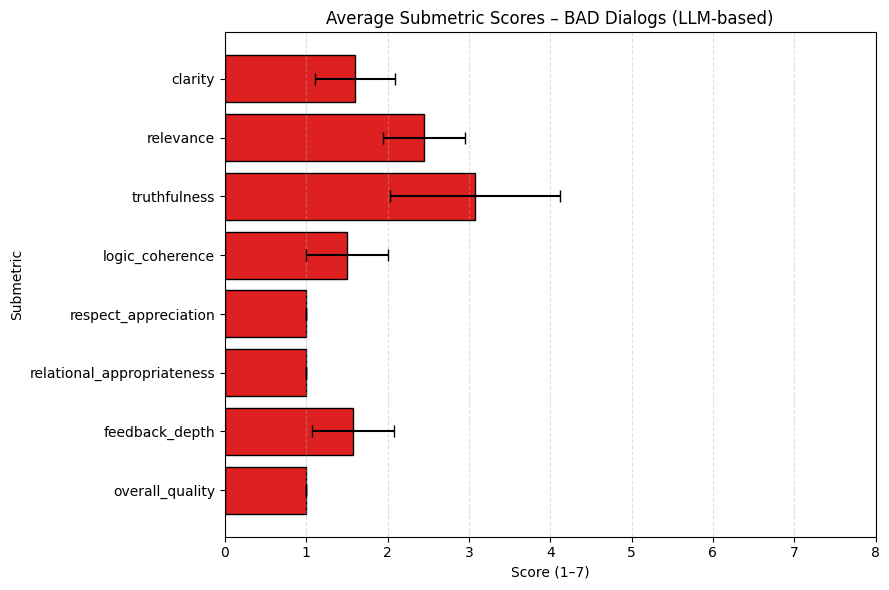

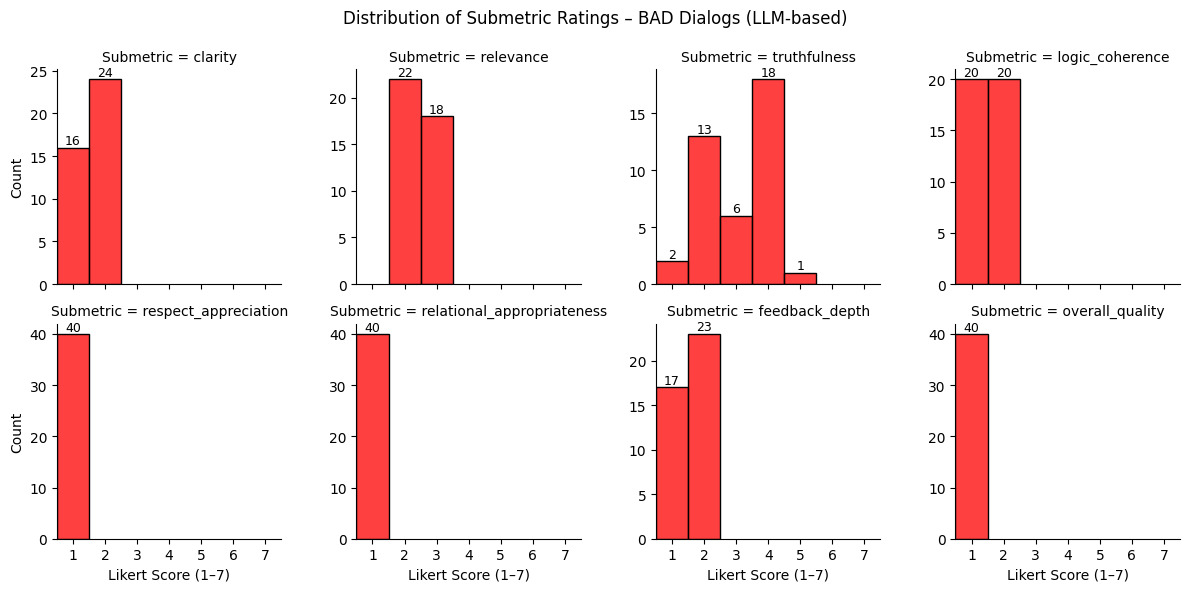

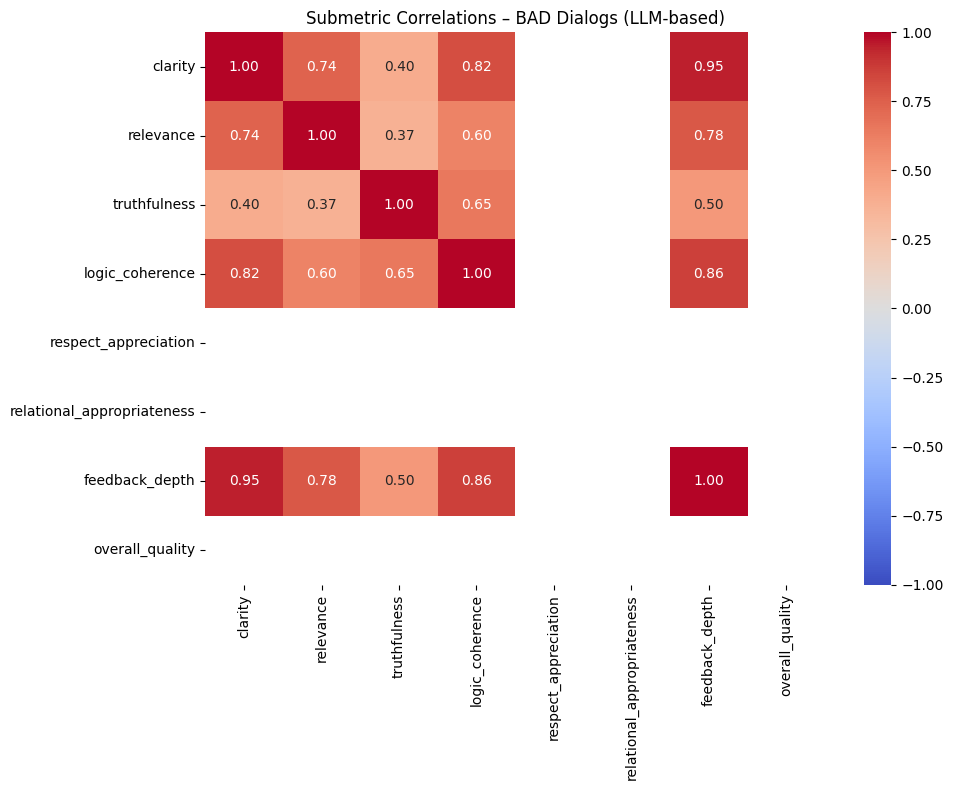

In [ ]:
# Run analysis for BAD dialogs

# Load LLM evaluations (BAD)
dialog_data_bad = load_dialog_json(OUTPUT_JSON_BAD)
df_llm_scores_bad = extract_submetrics_from_json(dialog_data_bad)

# Run analysis (BAD)
correlation_matrix_bad = analyze_submetric_distribution(df_llm_scores_bad)

## 10. Visualization of Submetrics (rule-based) and Communication Quality

In [ ]:
# Load dialogsand flatten to df_dialogs

import json, re, csv

def sanitize_text(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = s.replace("\\n", "\n")
    s = s.replace('\\"', '"').replace("\\'", "'")
    s = re.sub(r"\\\\", r"\\", s)
    return s.strip()

# Load existing BAD JSON from Drive
with open(OUTPUT_JSON_BAD, "r", encoding="utf-8") as f:
    dialog_data_bad = json.load(f)

print(f"Loaded {len(dialog_data_bad)} BAD dialogs from: {OUTPUT_JSON_BAD}")

# Flatten to df_dialogs
flat_records_bad = []
for entry in dialog_data_bad:
    record = {
        "dialog_id":       entry.get("dialog_id", ""),
        "recipe_id":       entry.get("recipe_id", None),
        "recipe":          entry.get("recipe", ""),
        "condition":       entry.get("condition", "bad"),
        "generation_seed": entry.get("generation_seed", None),
        "fat_response":    sanitize_text(entry.get("fat_response_bad", "")),
        "carb_response":   sanitize_text(entry.get("carb_response_bad", "")),
        "discussion":      sanitize_text(entry.get("discussion_bad", "")),
        "evaluation_raw":  sanitize_text(entry.get("evaluation_bad", "")),
    }
    eval_json = entry.get("evaluation_json_bad", {})
    if isinstance(eval_json, str):
        try:
            eval_json = json.loads(eval_json)
        except Exception:
            eval_json = {}
    if isinstance(eval_json, dict):
        for key in ["clarity", "relevance", "truthfulness", "logic_coherence",
                    "respect_appreciation", "relational_appropriateness",
                    "feedback_depth", "overall_quality"]:
            record[key] = eval_json.get(key, None)
    flat_records_bad.append(record)

df_dialogs_bad = pd.DataFrame(flat_records_bad)
print(f"df_dialogs_bad ready: {len(df_dialogs_bad)} rows")
display(df_dialogs_bad.head())

Loaded 40 BAD dialogs from: /content/drive/MyDrive/Masterarbeit/Dialoge/all_bad_dialogs_generated.json
df_dialogs_bad ready: 40 rows


,dialog_id,recipe_id,recipe,condition,generation_seed,fat_response,carb_response,discussion,evaluation_raw,clarity,relevance,truthfulness,logic_coherence,respect_appreciation,relational_appropriateness,feedback_depth,overall_quality
0,R000_B,0,Moong Dal,bad,42,The Moong Dal recipe contains 1.16685 g of fat...,"Moong Dal has 9.91822 g of carbohydrates, prov...","Fat: Whatever, it's got some fat.\nCarb: I thi...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
1,R001_B,1,Bourbon Wieners,bad,42,The Bourbon Wieners recipe contains 16.7136 g ...,The Bourbon Wieners recipe contains 19.6039 g ...,"Fat: Ugh, hot dogs have too much fat.\nCarb: W...","{\n ""clarity"": 1,\n ""relevance"": 2,\n ""trut...",1,2,3,1,1,1,1,1
2,R002_B,2,Pasta with Vietnamese Pesto,bad,42,"The fat content is 16.2666 g, approximately 30...","The carbohydrate content is 53.9309 g, roughly...","Fat: Ugh, too much oil.\nCarb: Whatever, it's ...","{\n ""clarity"": 1,\n ""relevance"": 2,\n ""trut...",1,2,2,1,1,1,1,1
3,R003_B,3,Cobb Salad Ham Roll-ups,bad,42,The Cobb Salad Ham Roll-ups contain 16.8109 g ...,"The recipe has 4.61133 g of carbohydrates, a r...","Fat: Whatever, it's got some fat.\nCarb: Ugh, ...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1
4,R004_B,4,Grain-Free Apple Cinnamon Dutch Babies,bad,42,"The fat content is 13.1152 g, approximately 30...","The carbohydrate content is 13.3551 g, roughly...","Fat: Whatever, it's got some fat.\nCarb: I thi...","{\n ""clarity"": 2,\n ""relevance"": 3,\n ""trut...",2,3,4,2,1,1,2,1


In [ ]:
# Calculate submetrics for each discussion

submetric_records = []

for i, row in tqdm(df_dialogs_bad.iterrows(), total=len(df_dialogs_bad), desc="Calculating submetrics"):
    discussion = row["discussion"]
    reference = row["fat_response"] + "\n" + row["carb_response"]
    scores = compute_all_submetrics(discussion, reference=reference)
    scores["dialog_id"] = row.get("dialog_id", "")
    scores["recipe_id"] = row.get("recipe_id", None)
    scores["recipe"] = row["recipe"]
    scores["condition"] = row.get("condition", "bad")
    submetric_records.append(scores)

# Create DataFrame with all submetric scores
df_scores = pd.DataFrame(submetric_records)

Calculating submetrics:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
# Save submetrics to CSV
df_scores.to_csv(SUBMETRIC_CSV_BAD, index=False)
print("Submetric scores saved to:", SUBMETRIC_CSV_BAD)

Submetric scores saved to: /content/drive/MyDrive/Masterarbeit/Dialoge/bad_submetric_scores.csv


In [ ]:
# Load Submetric Scores
df_scores = pd.read_csv(SUBMETRIC_CSV_BAD)

In [ ]:
# Radar Chart for Single Dialog Profile

def plot_radar_profile(row, title="Communication Profile BAD Dialogs"):
    """
    Plots radar chart for a single dialog using selected submetrics.
    One representative submetric per communication model.
    """
    labels = [
        "truthfulness",
        "clarity",
        "relational_appropriateness",
        "respect_appreciation",
        "logic_coherence",
        "feedback_depth",
        ]
    labels_display = [
        "Grice (Truth)",
        "Grice (Clarity)",
        "Schulz von Thun (Relation)",
        "Rogers (Respect)",
        "Watzlawick (Disturbance)",
        "Hargie (Feedback)",
    ]

    values = [row.get(l, 0) or 0 for l in labels]  # None-safe
    values += [values[0]]  # Close circle
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=True)

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2, color='crimson')
    ax.fill(angles, values, color='red', alpha=0.4)
    ax.set_yticklabels([])
    ax.set_ylim(0, 10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_display, fontsize=9)
    ax.set_title(title, size=13)

    for angle, value in zip(angles, values):
        ax.text(angle, value + 0.3, f"{value:.1f}", ha='center', va='center', fontsize=9)

    plt.show()

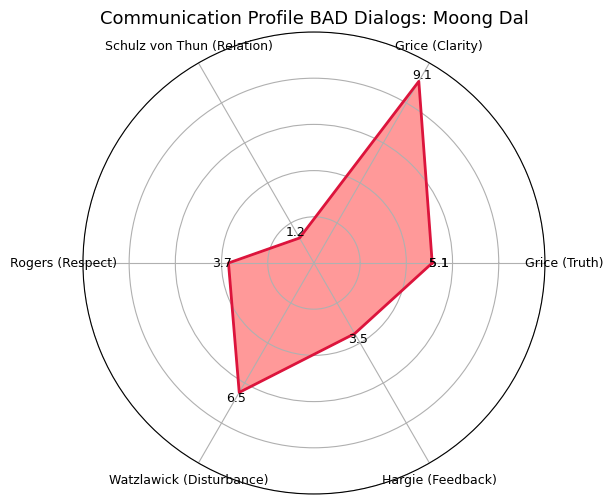

In [ ]:
# Plot for one dialog

idx = 0  # Show the first dialog or other index as required
plot_radar_profile(df_scores.iloc[idx], title=f"Communication Profile BAD Dialogs: {df_scores.iloc[idx]['recipe']}")

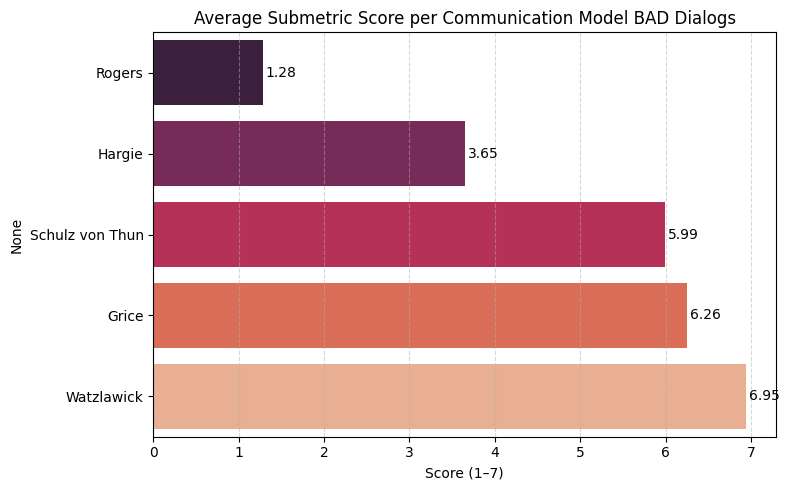

In [ ]:
# Average score per Communication Model

# Define groups
model_groups = {
    "Grice": ["grice_precision", "grice_relevance", "grice_truth", "grice_clarity"],
    "Schulz von Thun": ["thun_content", "thun_self", "thun_relation", "thun_appeal"],
    "Watzlawick": ["watzlawick_logic", "watzlawick_disturbance"],
    "Rogers": ["rogers_respect", "rogers_transparency", "rogers_appreciation"],
    "Hargie": ["hargie_feedback", "hargie_depth"]
}

# Compute model-wise means
model_means = {
    model: df_scores[cols].mean().mean()
    for model, cols in model_groups.items()
}

model_df = pd.DataFrame.from_dict(model_means, orient="index", columns=["Average"]).sort_values("Average")

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_df,
    x="Average",
    y=model_df.index,
    hue=model_df.index,
    palette="rocket",
    dodge=False,
    legend=False)
plt.title("Average Submetric Score per Communication Model BAD Dialogs")
plt.xlabel("Score (1–7)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Add the value labels at the end of each bar
for i, (avg, model_name) in enumerate(zip(model_df["Average"], model_df.index)):
    plt.text(
        avg + 0.03,       # slightly to the right of the bar
        i,                # y-location of bar
        f"{avg:.2f}",     # show value with two decimals
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.show()

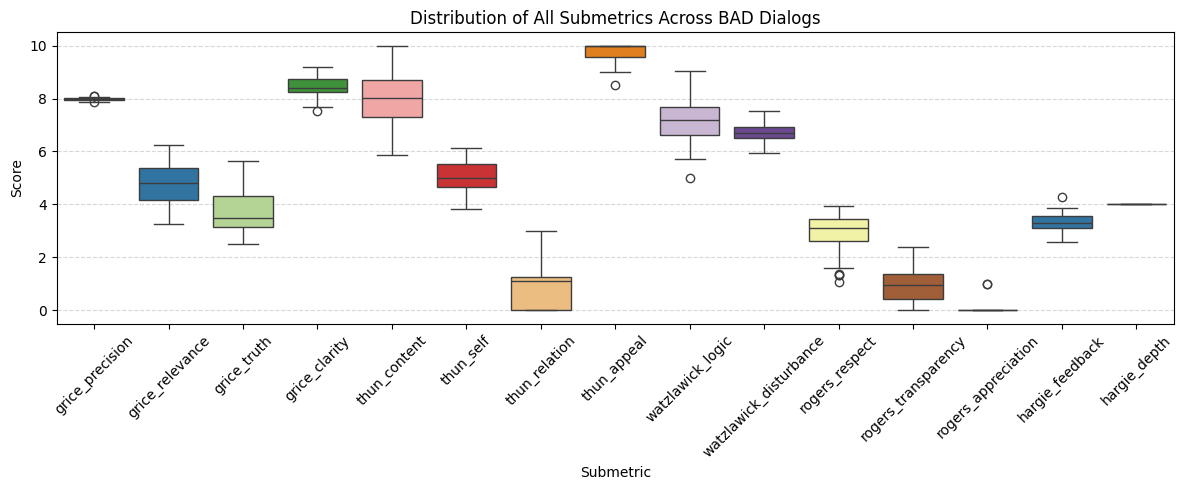

In [ ]:
# Boxplot of all submetrics (rule-based)

# Select only numeric submetric columns
numeric_cols = df_scores.select_dtypes(include="number").columns.tolist()

for col in ["recipe_id", "generation_seed"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

# Long-Format for Plot
long_df = df_scores.melt(
    id_vars="recipe",
    value_vars=numeric_cols,
    var_name="Submetric",
    value_name="Score"
)

long_df = long_df[long_df["Submetric"].str.contains("_")]

# Plot
plt.figure(figsize=(12, 5))
sns.boxplot(data=long_df,
            x="Submetric",
            y="Score",
            hue="Submetric",
            legend=False,
            palette="Paired")
plt.xticks(rotation=45)
plt.title("Distribution of All Submetrics Across BAD Dialogs")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

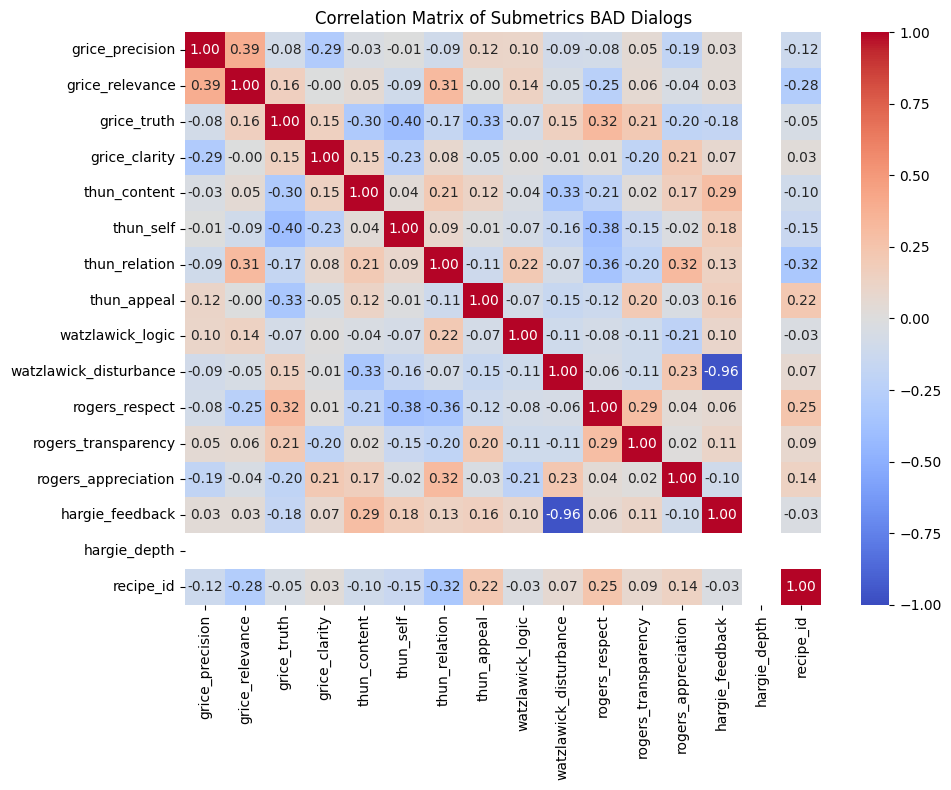

In [ ]:
# Correlation Matrix of Submetrics

numeric_cols = df_scores.select_dtypes(include="number").columns.tolist()
corr_matrix = df_scores[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Submetrics BAD Dialogs")
plt.tight_layout()
plt.show()